# Hack-o-Week — Weeks 9 & 10
## Model Evaluation · scikit-learn Pipelines · Clustering

**Dataset:** `student_habits_performance.csv`

Week 7–8 built models and trusted a single train/test split. That is not good enough.
This notebook is about **knowing whether your model is actually any good**, wrapping the
whole workflow so it cannot leak, and then dropping the labels entirely to find structure
on your own.

### Roadmap
| Part | Topic |
|---|---|
| A | Train/test split, and why one split lies to you |
| B | Cross-validation: KFold, StratifiedKFold, `cross_validate` |
| C | Confusion matrix, precision, recall, F1 — and which one to optimise |
| D | ROC-AUC, precision–recall curves, threshold tuning |
| E | `Pipeline` + `ColumnTransformer` + `GridSearchCV` |
| F | Clustering: K-Means, Hierarchical, DBSCAN |
| G | Saving and reloading the finished model |

### 0 · Setup

In [1]:
import os
import numpy as np
import pandas as pd

FILENAME = "student_habits_performance.csv"

# Works whether you run this notebook from the repo (notebooks/ folder),
# from the repo root, or in Google Colab.
CANDIDATES = [
    FILENAME,
    os.path.join("data", FILENAME),
    os.path.join("..", "data", FILENAME),
    os.path.join("/content", FILENAME),
]

DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

if DATA_PATH is None:
    try:  # running in Colab without the repo -> upload the CSV once
        from google.colab import files
        print("CSV not found. Please upload student_habits_performance.csv")
        files.upload()
        DATA_PATH = FILENAME
    except ImportError:
        raise FileNotFoundError(
            "Put student_habits_performance.csv in a data/ folder next to this notebook."
        )

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, "| shape:", df.shape)
df.head()

Loaded: ../data/student_habits_performance.csv | shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print("plotting configured")

plotting configured


In [3]:
from sklearn.model_selection import (train_test_split, cross_val_score, cross_validate,
                                     KFold, StratifiedKFold, GridSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, precision_score, recall_score,
                             f1_score, accuracy_score, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score,
                             silhouette_score, silhouette_samples)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

RANDOM_STATE = 42
print("imports ready")

imports ready


In [4]:
data = df.copy()

NUMERIC = ["age", "study_hours_per_day", "social_media_hours", "netflix_hours",
           "attendance_percentage", "sleep_hours", "exercise_frequency",
           "mental_health_rating"]
CATEGORICAL = ["gender", "part_time_job", "diet_quality", "parental_education_level",
               "internet_quality", "extracurricular_participation"]

X = data[NUMERIC + CATEGORICAL]          # note: parental_education_level still has NaNs!
y_reg = data["exam_score"].to_numpy()
y_clf = (data["exam_score"] >= 60).astype(int).to_numpy()

print("X:", X.shape, "| NaNs:", int(X.isna().sum().sum()))
print(f"class balance: {np.bincount(y_clf)}  ->  {y_clf.mean():.1%} pass")

X: (1000, 14) | NaNs: 91
class balance: [280 720]  ->  72.0% pass


---
# Part A · Why one train/test split is not enough

A single split gives you **one number from one random partition**. Change
`random_state` and the number changes. If you tune your model until that one number looks
good, you have fitted your *hyperparameters* to the test set — and your reported score is
optimistic.

Let's measure exactly how unstable a single split is.

30 different random splits of the SAME data, the SAME model:
  min 0.8750 | max 0.9500 | spread 0.0750
  mean 0.9242 ± 0.0166


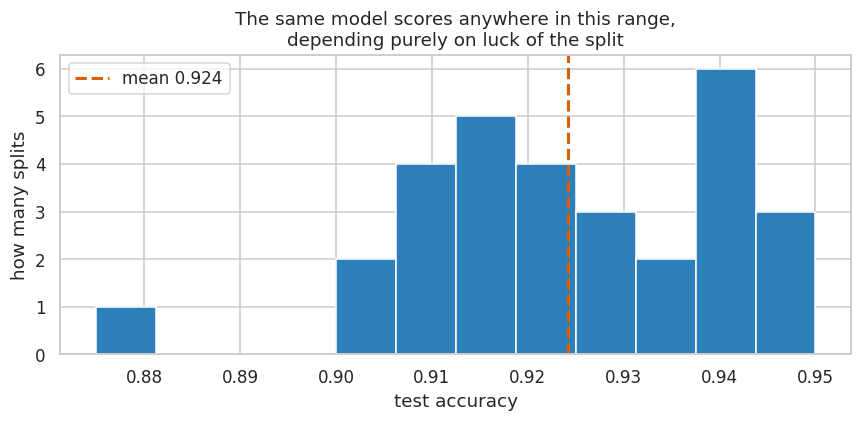

In [5]:
# Build a quick numeric-only design matrix for this demonstration
Xn = data[NUMERIC].to_numpy()

single_split_scores = []
for seed in range(30):
    Xtr, Xte, ytr, yte = train_test_split(Xn, y_clf, test_size=0.2,
                                          random_state=seed, stratify=y_clf)
    sc = StandardScaler().fit(Xtr)
    m = LogisticRegression(max_iter=2000).fit(sc.transform(Xtr), ytr)
    single_split_scores.append(m.score(sc.transform(Xte), yte))

single_split_scores = np.array(single_split_scores)
print(f"30 different random splits of the SAME data, the SAME model:")
print(f"  min {single_split_scores.min():.4f} | max {single_split_scores.max():.4f} "
      f"| spread {single_split_scores.max()-single_split_scores.min():.4f}")
print(f"  mean {single_split_scores.mean():.4f} ± {single_split_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(single_split_scores, bins=12, color="#2c7fb8", edgecolor="white")
ax.axvline(single_split_scores.mean(), color="#d95f02", ls="--", lw=2,
           label=f"mean {single_split_scores.mean():.3f}")
ax.set_xlabel("test accuracy"); ax.set_ylabel("how many splits")
ax.set_title("The same model scores anywhere in this range,\ndepending purely on luck of the split")
ax.legend(); fig.tight_layout(); plt.show()

That spread is the point. Quoting a single split's accuracy to three decimal places is
false precision. **Cross-validation** averages over many splits so you get a mean *and* a
standard deviation.

### The three-way split you should actually use

| Set | Used for | How often you touch it |
|---|---|---|
| **Train** | fitting model parameters | every fit |
| **Validation** | choosing hyperparameters | many times |
| **Test** | final honest estimate | **once, at the very end** |

Cross-validation replaces the validation set by rotating it through the training data.

---
# Part B · Cross-validation

**K-fold CV:** split the data into `k` equal parts. Train on `k-1`, validate on the
remaining one. Repeat `k` times so every row is validated exactly once. Average the scores.

| Variant | Use when |
|---|---|
| `KFold` | regression, balanced data |
| `StratifiedKFold` | **classification** — preserves the class ratio in each fold |
| `GroupKFold` | rows are grouped (same patient, same school) and must not straddle folds |
| `TimeSeriesSplit` | temporal data — never train on the future |

`k=5` or `k=10` is standard. Higher `k` = less bias, more compute.

In [6]:
pipe_demo = Pipeline([("scaler", StandardScaler()),
                      ("clf", LogisticRegression(max_iter=2000))])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipe_demo, Xn, y_clf, cv=skf, scoring="accuracy")

print("fold accuracies:", cv_scores.round(4))
print(f"\nCV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"95% interval : [{cv_scores.mean()-2*cv_scores.std():.4f}, "
      f"{cv_scores.mean()+2*cv_scores.std():.4f}]")
print("\nThis is what you report — a mean and an uncertainty, not one lucky number.")

fold accuracies: [0.94  0.935 0.905 0.92  0.9  ]

CV accuracy: 0.9200 ± 0.0158
95% interval : [0.8884, 0.9516]

This is what you report — a mean and an uncertainty, not one lucky number.


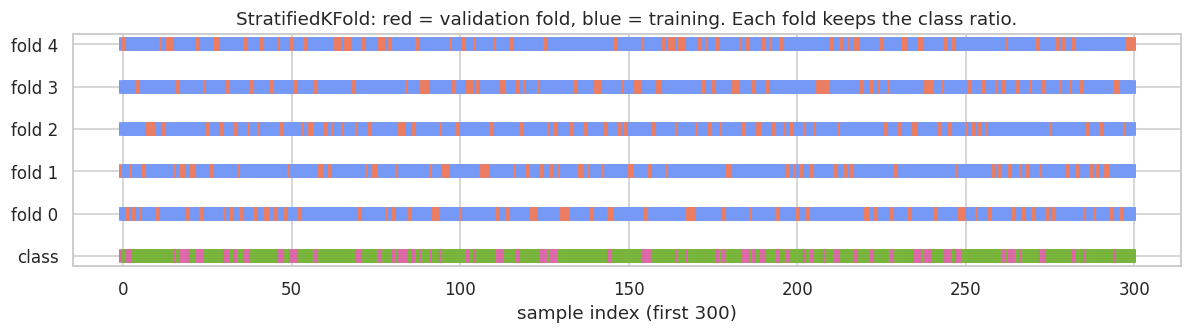

In [7]:
# Visualise what StratifiedKFold actually does
fig, ax = plt.subplots(figsize=(11, 3.2))
n_show = 300
for fold, (tr_idx, te_idx) in enumerate(skf.split(Xn[:n_show], y_clf[:n_show])):
    indicator = np.zeros(n_show)
    indicator[te_idx] = 1
    ax.scatter(range(n_show), [fold] * n_show, c=indicator, marker="_", lw=9,
               cmap="coolwarm", vmin=-0.3, vmax=1.3)
ax.scatter(range(n_show), [-1] * n_show, c=y_clf[:n_show], marker="_", lw=9,
           cmap="PiYG", vmin=-0.3, vmax=1.3)
ax.set_yticks(list(range(5)) + [-1])
ax.set_yticklabels([f"fold {i}" for i in range(5)] + ["class"])
ax.set_xlabel("sample index (first 300)")
ax.set_title("StratifiedKFold: red = validation fold, blue = training. "
             "Each fold keeps the class ratio.")
fig.tight_layout(); plt.show()

In [8]:
# cross_validate gives you SEVERAL metrics plus train scores, in one pass
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_res = cross_validate(pipe_demo, Xn, y_clf, cv=skf, scoring=scoring,
                        return_train_score=True)

summary = pd.DataFrame({
    m: [cv_res[f"test_{m}"].mean(), cv_res[f"test_{m}"].std(),
        cv_res[f"train_{m}"].mean()]
    for m in scoring
}, index=["test_mean", "test_std", "train_mean"]).T.round(4)
print(summary.to_string())
print("\ntrain ≈ test on every metric -> the model is NOT overfitting.")

           test_mean  test_std  train_mean
accuracy      0.9200    0.0158      0.9305
precision     0.9350    0.0138      0.9425
recall        0.9556    0.0173      0.9622
f1            0.9450    0.0110      0.9522
roc_auc       0.9734    0.0059      0.9780

train ≈ test on every metric -> the model is NOT overfitting.


k= 2: 0.9250 ± 0.0130
k= 3: 0.9220 ± 0.0186
k= 5: 0.9200 ± 0.0158
k=10: 0.9200 ± 0.0286


k=20: 0.9240 ± 0.0294


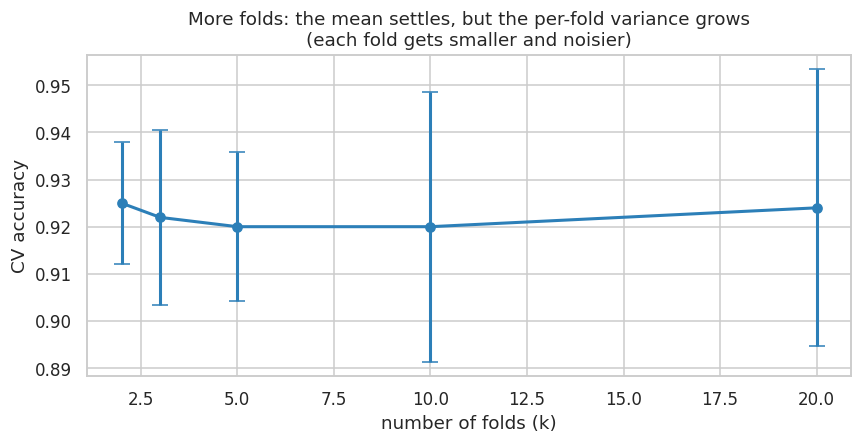

In [9]:
# How many folds? Watch the estimate stabilise.
fold_range = [2, 3, 5, 10, 20]
means, stds = [], []
for k in fold_range:
    s = cross_val_score(pipe_demo, Xn, y_clf,
                        cv=StratifiedKFold(k, shuffle=True, random_state=RANDOM_STATE))
    means.append(s.mean()); stds.append(s.std())
    print(f"k={k:>2}: {s.mean():.4f} ± {s.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.errorbar(fold_range, means, yerr=stds, marker="o", capsize=5,
            color="#2c7fb8", lw=2)
ax.set_xlabel("number of folds (k)"); ax.set_ylabel("CV accuracy")
ax.set_title("More folds: the mean settles, but the per-fold variance grows\n"
             "(each fold gets smaller and noisier)")
fig.tight_layout(); plt.show()

---
# Part C · Confusion matrix, precision, recall, F1

Accuracy alone is dangerous. If 95% of students pass, a model that predicts "pass" for
everyone scores 95% accuracy and is completely useless — it never catches the students who
need help. You need to know **what kind** of mistakes the model makes.

|  | predicted fail | predicted pass |
|---|---|---|
| **actually fail** | TN | FP |
| **actually pass** | FN | TP |

$$\text{precision} = \frac{TP}{TP+FP}\quad
\text{recall} = \frac{TP}{TP+FN}\quad
F_1 = 2\cdot\frac{P\cdot R}{P+R}$$

- **Precision**: of everything I flagged, how much was right? (cost of a false alarm)
- **Recall**: of everything I should have found, how much did I catch? (cost of a miss)
- **F1**: their harmonic mean — punishes a model that is good at one and bad at the other.

**Which one matters is a domain decision, not a maths decision.** For "which students are
at risk of failing", a miss (a struggling student you never contacted) is far worse than a
false alarm (an extra check-in). So you optimise **recall on the failing class**.

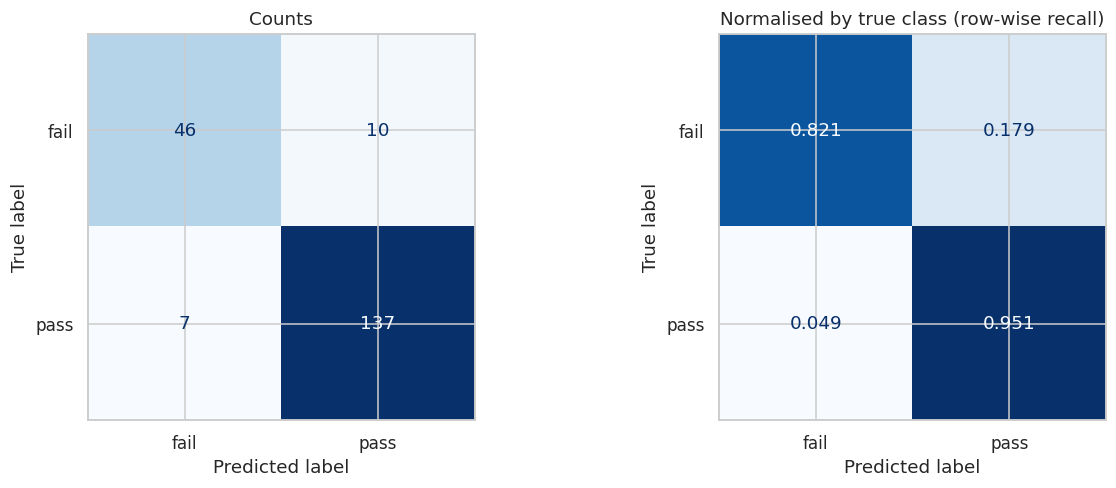

TN=46  FP=10
FN=7  TP=137

accuracy  = (TP+TN)/all = 0.9150
precision = TP/(TP+FP)  = 0.9320
recall    = TP/(TP+FN)  = 0.9514
F1        =             = 0.9416


In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(Xn, y_clf, test_size=0.2,
                                          random_state=RANDOM_STATE, stratify=y_clf)
pipe = Pipeline([("scaler", StandardScaler()),
                 ("clf", LogisticRegression(max_iter=2000))]).fit(X_tr, y_tr)

y_pred = pipe.predict(X_te)
y_proba = pipe.predict_proba(X_te)[:, 1]

cm = confusion_matrix(y_te, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ConfusionMatrixDisplay(cm, display_labels=["fail", "pass"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Counts")
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred, normalize="true"),
                       display_labels=["fail", "pass"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".3f")
axes[1].set_title("Normalised by true class (row-wise recall)")
fig.tight_layout(); plt.show()

print(f"TN={tn}  FP={fp}\nFN={fn}  TP={tp}\n")
print(f"accuracy  = (TP+TN)/all = {(tp+tn)/cm.sum():.4f}")
print(f"precision = TP/(TP+FP)  = {tp/(tp+fp):.4f}")
print(f"recall    = TP/(TP+FN)  = {tp/(tp+fn):.4f}")
print(f"F1        =             = {2*tp/(2*tp+fp+fn):.4f}")

In [11]:
print(classification_report(y_te, y_pred, target_names=["fail", "pass"], digits=3))
print("""
How to read this:
  - each row is one class treated as 'positive'
  - 'support' = how many test samples are actually in that class
  - 'macro avg'    = unweighted mean of the two rows -> treats both classes as equally important
  - 'weighted avg' = weighted by support -> dominated by the majority class
With imbalanced data, quote the MACRO average or the minority-class row, never accuracy.
""")

              precision    recall  f1-score   support

        fail      0.868     0.821     0.844        56
        pass      0.932     0.951     0.942       144

    accuracy                          0.915       200
   macro avg      0.900     0.886     0.893       200
weighted avg      0.914     0.915     0.914       200


How to read this:
  - each row is one class treated as 'positive'
  - 'support' = how many test samples are actually in that class
  - 'macro avg'    = unweighted mean of the two rows -> treats both classes as equally important
  - 'weighted avg' = weighted by support -> dominated by the majority class
With imbalanced data, quote the MACRO average or the minority-class row, never accuracy.



In [12]:
# The baseline every classifier must beat
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
print(f"'always predict pass' accuracy : {dummy.score(X_te, y_te):.4f}")
print(f"logistic regression accuracy   : {pipe.score(X_te, y_te):.4f}")
print(f"\nimprovement over the trivial baseline: "
      f"{pipe.score(X_te, y_te) - dummy.score(X_te, y_te):+.4f}")
print("\nAlways compute this. A model that cannot beat DummyClassifier has learned nothing.")

'always predict pass' accuracy : 0.7200
logistic regression accuracy   : 0.9150

improvement over the trivial baseline: +0.1950

Always compute this. A model that cannot beat DummyClassifier has learned nothing.


---
# Part D · ROC-AUC, PR curves, and threshold tuning

`predict()` secretly applies a threshold of 0.5 to `predict_proba()`. **That threshold is a
choice, not a law.** Lower it and you catch more positives but raise more false alarms.

- **ROC curve**: true positive rate vs false positive rate, across every threshold.
  **AUC** = area under it = the probability that a random positive is ranked above a random
  negative. 0.5 = coin flip, 1.0 = perfect.
- **Precision–Recall curve**: better than ROC when the classes are **imbalanced**, because
  it ignores the (usually huge and uninteresting) true-negative count.

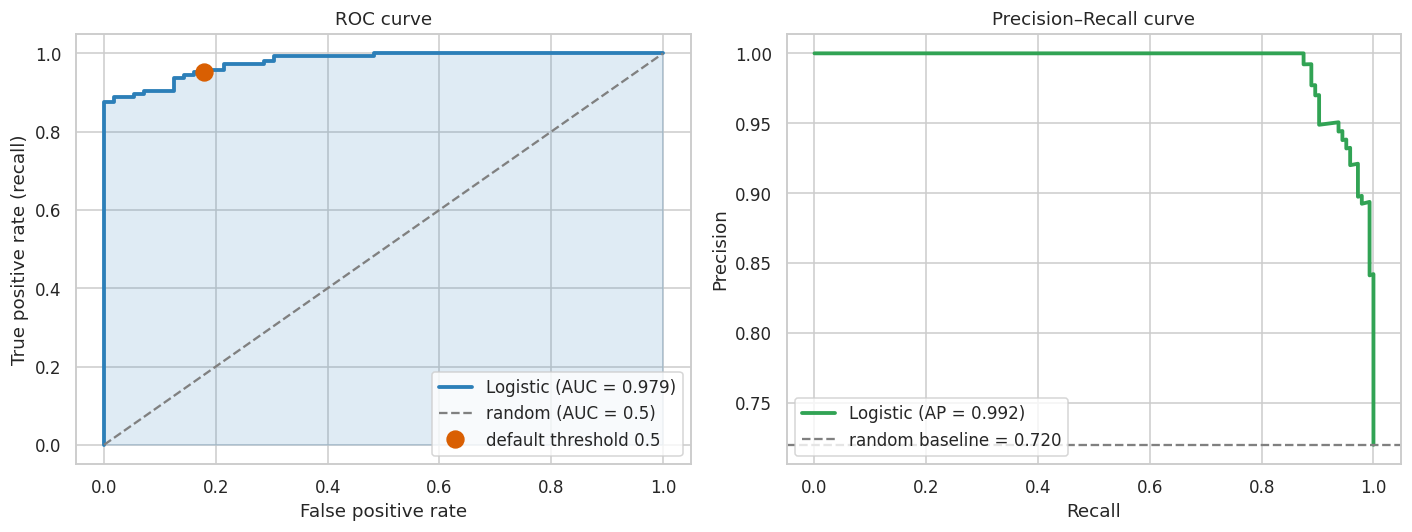

In [13]:
fpr, tpr, roc_thresh = roc_curve(y_te, y_proba)
auc = roc_auc_score(y_te, y_proba)
prec, rec, pr_thresh = precision_recall_curve(y_te, y_proba)
ap = average_precision_score(y_te, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, lw=2.5, color="#2c7fb8", label=f"Logistic (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="random (AUC = 0.5)")
axes[0].fill_between(fpr, tpr, alpha=0.15, color="#2c7fb8")
idx = np.argmin(np.abs(roc_thresh - 0.5))
axes[0].plot(fpr[idx], tpr[idx], "o", ms=11, color="#d95f02", label="default threshold 0.5")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate (recall)")
axes[0].set_title("ROC curve"); axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, lw=2.5, color="#31a354", label=f"Logistic (AP = {ap:.3f})")
axes[1].axhline(y_te.mean(), ls="--", color="gray",
                label=f"random baseline = {y_te.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall curve"); axes[1].legend(loc="lower left")

fig.tight_layout(); plt.show()

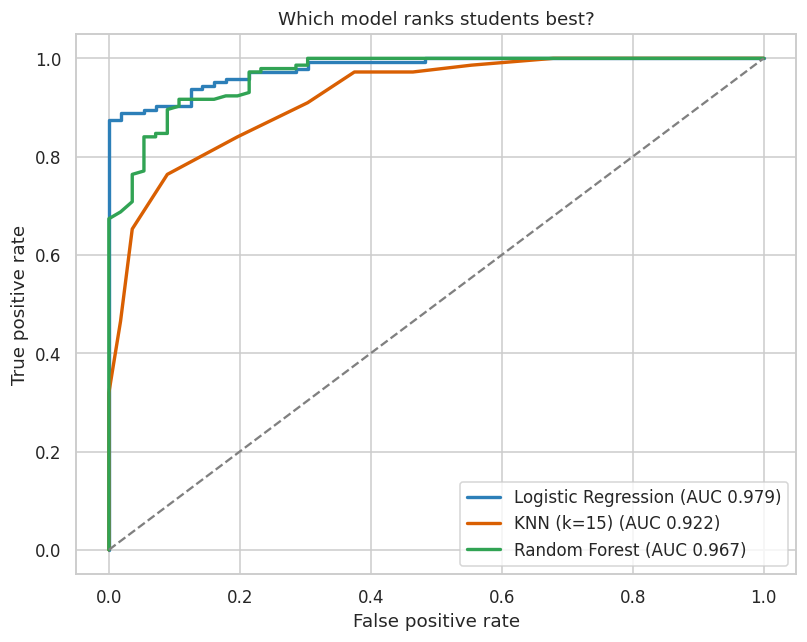

                     accuracy  precision  recall      f1  roc_auc
model                                                            
Logistic Regression     0.915     0.9320  0.9514  0.9416   0.9787
KNN (k=15)              0.850     0.8434  0.9722  0.9032   0.9216
Random Forest           0.905     0.9195  0.9514  0.9352   0.9670


In [14]:
# Compare three models on one ROC plot — this is how you actually choose
models = {
    "Logistic Regression": Pipeline([("s", StandardScaler()),
                                     ("m", LogisticRegression(max_iter=2000))]),
    "KNN (k=15)": Pipeline([("s", StandardScaler()),
                            ("m", KNeighborsClassifier(15))]),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

fig, ax = plt.subplots(figsize=(7.5, 6))
rows = []
for (name, model), colr in zip(models.items(), ["#2c7fb8", "#d95f02", "#31a354"]):
    model.fit(X_tr, y_tr)
    p = model.predict_proba(X_te)[:, 1]
    f, t, _ = roc_curve(y_te, p)
    a = roc_auc_score(y_te, p)
    ax.plot(f, t, lw=2.2, color=colr, label=f"{name} (AUC {a:.3f})")
    pred = model.predict(X_te)
    rows.append({"model": name, "accuracy": accuracy_score(y_te, pred),
                 "precision": precision_score(y_te, pred),
                 "recall": recall_score(y_te, pred),
                 "f1": f1_score(y_te, pred), "roc_auc": a})

ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Which model ranks students best?"); ax.legend(loc="lower right")
fig.tight_layout(); plt.show()

print(pd.DataFrame(rows).set_index("model").round(4).to_string())

### Tuning the threshold

Our real goal is *catching students who will fail*. So flip the problem: treat **fail** as
the positive class and find the threshold that maximises recall on it without destroying
precision.

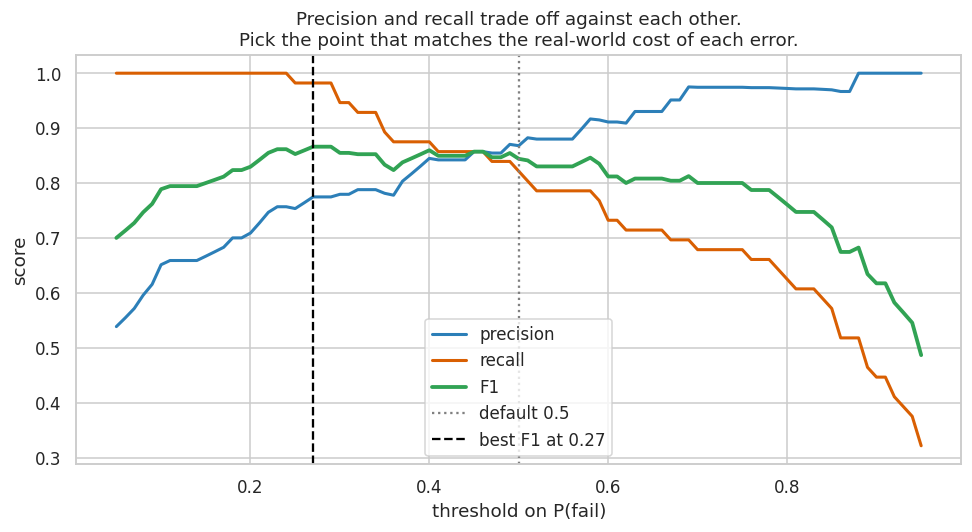

Default threshold 0.50:
  precision 0.868 | recall 0.821 | F1 0.844

Best-F1 threshold 0.27:
  precision 0.775 | recall 0.982 | F1 0.866

If a missed at-risk student is 3x costlier than a false alarm, threshold 0.30:
  precision 0.779 | recall 0.946   <- catches more, at the cost of more false alarms


In [15]:
proba_fail = 1 - y_proba              # P(fail)
y_fail = 1 - y_te                     # 1 = actually failed

thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds:
    pred_fail = (proba_fail >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_fail, pred_fail, zero_division=0),
        "recall": recall_score(y_fail, pred_fail, zero_division=0),
        "f1": f1_score(y_fail, pred_fail, zero_division=0),
    })
tdf = pd.DataFrame(rows)
best_f1 = tdf.loc[tdf["f1"].idxmax()]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tdf["threshold"], tdf["precision"], lw=2, label="precision", color="#2c7fb8")
ax.plot(tdf["threshold"], tdf["recall"], lw=2, label="recall", color="#d95f02")
ax.plot(tdf["threshold"], tdf["f1"], lw=2.5, label="F1", color="#31a354")
ax.axvline(0.5, ls=":", color="gray", label="default 0.5")
ax.axvline(best_f1["threshold"], ls="--", color="black",
           label=f"best F1 at {best_f1['threshold']:.2f}")
ax.set_xlabel("threshold on P(fail)"); ax.set_ylabel("score")
ax.set_title("Precision and recall trade off against each other.\n"
             "Pick the point that matches the real-world cost of each error.")
ax.legend(); fig.tight_layout(); plt.show()

print("Default threshold 0.50:")
d = tdf.iloc[np.argmin(np.abs(tdf['threshold'] - 0.5))]
print(f"  precision {d['precision']:.3f} | recall {d['recall']:.3f} | F1 {d['f1']:.3f}")
print(f"\nBest-F1 threshold {best_f1['threshold']:.2f}:")
print(f"  precision {best_f1['precision']:.3f} | recall {best_f1['recall']:.3f} "
      f"| F1 {best_f1['f1']:.3f}")

lowered = tdf.iloc[np.argmin(np.abs(tdf['threshold'] - 0.30))]
print(f"\nIf a missed at-risk student is 3x costlier than a false alarm, threshold 0.30:")
print(f"  precision {lowered['precision']:.3f} | recall {lowered['recall']:.3f} "
      "  <- catches more, at the cost of more false alarms")

---
# Part E · Pipelines — the professional workflow

Everything so far had a hidden risk: you had to remember to fit the scaler on train only,
in the right order, every time. A `Pipeline` chains the steps into **one object** that
behaves like a model:

- `pipe.fit(X_train, y_train)` fits every step in order.
- `pipe.predict(X_test)` applies each fitted transform, then the model.
- Inside cross-validation, the transforms are **re-fitted on each fold's training portion**.
  That makes data leakage structurally impossible.

`ColumnTransformer` lets different columns take different routes — numeric columns get
imputed and scaled, categorical columns get imputed and one-hot encoded.

In [16]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, NUMERIC),
    ("cat", categorical_pipe, CATEGORICAL),
])

full_pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

full_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [17]:
# One object handles the raw DataFrame — NaNs, strings and all
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

full_pipe.fit(Xf_tr, yf_tr)
print("test accuracy:", round(full_pipe.score(Xf_te, yf_te), 4))
print("NaNs in the raw input:", int(Xf_tr.isna().sum().sum()), "-> handled by the imputer")

feature_names = full_pipe.named_steps["prep"].get_feature_names_out()
print(f"\n{len(feature_names)} engineered features:")
print(list(feature_names))

test accuracy: 0.925
NaNs in the raw input: 71 -> handled by the imputer

18 engineered features:
['num__age', 'num__study_hours_per_day', 'num__social_media_hours', 'num__netflix_hours', 'num__attendance_percentage', 'num__sleep_hours', 'num__exercise_frequency', 'num__mental_health_rating', 'cat__gender_Male', 'cat__gender_Other', 'cat__part_time_job_Yes', 'cat__diet_quality_Good', 'cat__diet_quality_Poor', 'cat__parental_education_level_High School', 'cat__parental_education_level_Master', 'cat__internet_quality_Good', 'cat__internet_quality_Poor', 'cat__extracurricular_participation_Yes']


In [18]:
# Now cross-validate the WHOLE pipeline — imputation and scaling refit inside each fold
cv_full = cross_validate(full_pipe, X, y_clf, cv=skf,
                         scoring=["accuracy", "f1", "roc_auc"], return_train_score=True)
for m in ["accuracy", "f1", "roc_auc"]:
    print(f"{m:>9}: {cv_full['test_'+m].mean():.4f} ± {cv_full['test_'+m].std():.4f}")
print("\nNo leakage is possible here — that is the whole point of a Pipeline.")

 accuracy: 0.9150 ± 0.0184
       f1: 0.9414 ± 0.0129
  roc_auc: 0.9725 ± 0.0054

No leakage is possible here — that is the whole point of a Pipeline.


## GridSearchCV — hyperparameter tuning done right

`GridSearchCV` tries every combination in a grid, scoring each with cross-validation, and
refits the best one on all the training data. Address a step's parameter with
`stepname__paramname` (double underscore).

In [19]:
param_grid = {
    "prep__num__impute__strategy": ["mean", "median"],
    "clf__C": [0.01, 0.1, 1, 10, 100],
}

grid = GridSearchCV(full_pipe, param_grid, cv=skf, scoring="roc_auc",
                    n_jobs=-1, return_train_score=True)
grid.fit(Xf_tr, yf_tr)

print("best params:", grid.best_params_)
print(f"best CV ROC-AUC : {grid.best_score_:.4f}")
print(f"held-out test AUC: "
      f"{roc_auc_score(yf_te, grid.predict_proba(Xf_te)[:, 1]):.4f}")

cv_table = (pd.DataFrame(grid.cv_results_)
            [["param_clf__C", "param_prep__num__impute__strategy",
              "mean_test_score", "std_test_score", "mean_train_score"]]
            .sort_values("mean_test_score", ascending=False).round(4))
print("\nAll combinations tried:")
print(cv_table.to_string(index=False))

best params: {'clf__C': 0.1, 'prep__num__impute__strategy': 'mean'}
best CV ROC-AUC : 0.9741
held-out test AUC: 0.9774

All combinations tried:
 param_clf__C param_prep__num__impute__strategy  mean_test_score  std_test_score  mean_train_score
         0.10                            median           0.9741          0.0131            0.9793
         0.10                              mean           0.9741          0.0131            0.9793
         0.01                            median           0.9735          0.0142            0.9778
         0.01                              mean           0.9735          0.0142            0.9778
         1.00                              mean           0.9733          0.0127            0.9799
         1.00                            median           0.9733          0.0127            0.9799
        10.00                              mean           0.9728          0.0130            0.9800
        10.00                            median           0.9728

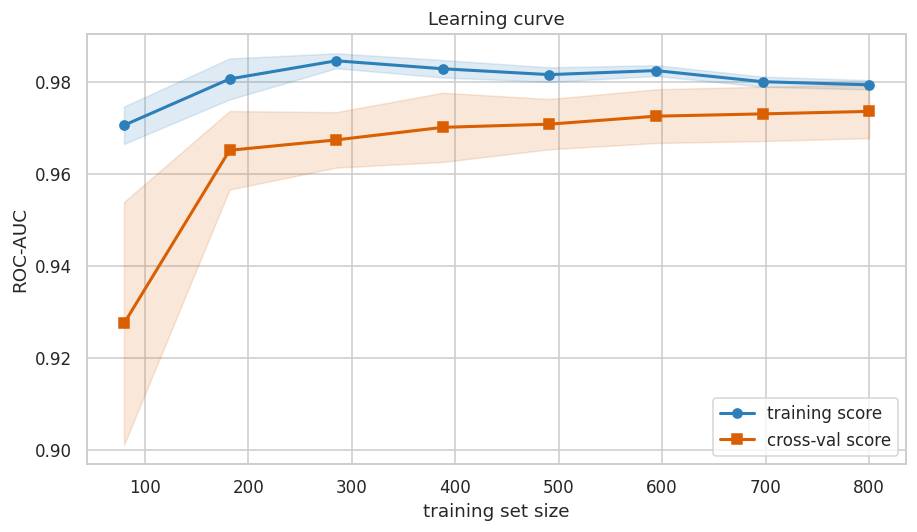

How to read a learning curve:
  curves converge, both HIGH  -> good model, more data will not help much
  curves converge, both LOW   -> underfitting: you need a more expressive model
  big persistent GAP          -> overfitting: get more data, or regularise harder



In [20]:
# Learning curve: is more DATA or a better MODEL what you need?
sizes, train_sc, val_sc = learning_curve(
    grid.best_estimator_, X, y_clf, cv=skf, scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(sizes, train_sc.mean(axis=1), "o-", color="#2c7fb8", lw=2, label="training score")
ax.fill_between(sizes, train_sc.mean(1)-train_sc.std(1), train_sc.mean(1)+train_sc.std(1),
                alpha=0.15, color="#2c7fb8")
ax.plot(sizes, val_sc.mean(axis=1), "s-", color="#d95f02", lw=2, label="cross-val score")
ax.fill_between(sizes, val_sc.mean(1)-val_sc.std(1), val_sc.mean(1)+val_sc.std(1),
                alpha=0.15, color="#d95f02")
ax.set_xlabel("training set size"); ax.set_ylabel("ROC-AUC")
ax.set_title("Learning curve")
ax.legend(); fig.tight_layout(); plt.show()

print("""How to read a learning curve:
  curves converge, both HIGH  -> good model, more data will not help much
  curves converge, both LOW   -> underfitting: you need a more expressive model
  big persistent GAP          -> overfitting: get more data, or regularise harder
""")

---
# Part F · Clustering (unsupervised learning)

Now throw the labels away. **Clustering** asks: does this data fall into natural groups?

There is no "accuracy" here — no ground truth to compare against. You judge clusters by
internal measures (silhouette) and, above all, by **whether the groups mean anything**.

| Algorithm | Idea | Shape it finds | Needs `k`? | Handles noise? |
|---|---|---|---|---|
| **K-Means** | minimise distance to `k` centroids | spherical, similar size | yes | no |
| **Hierarchical** | repeatedly merge the closest pair | any, nested | no (cut the tree) | no |
| **DBSCAN** | dense regions separated by sparse ones | arbitrary | no | **yes** |

Everything below uses **scaled** features — clustering is entirely distance-based.

In [21]:
CLUSTER_FEATURES = ["study_hours_per_day", "social_media_hours", "netflix_hours",
                    "attendance_percentage", "sleep_hours", "exercise_frequency",
                    "mental_health_rating"]

Xc = data[CLUSTER_FEATURES].to_numpy()
Xc_scaled = StandardScaler().fit_transform(Xc)

# A 2-D PCA projection, purely so we can SEE the clusters (Week 5-6 technique)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Xc_2d = pca.fit_transform(Xc_scaled)
print("clustering on", Xc_scaled.shape, "features")
print("PCA projection explains",
      f"{pca.explained_variance_ratio_.sum():.1%} of the variance "
      "(low, so the 2-D picture is only a rough guide)")

clustering on (1000, 7) features
PCA projection explains 30.3% of the variance (low, so the 2-D picture is only a rough guide)


## F1 · K-Means

1. Place `k` centroids at random.
2. Assign every point to its nearest centroid.
3. Move each centroid to the mean of its points.
4. Repeat until nothing moves.

It minimises **inertia** = total squared distance from points to their centroid.
Inertia always falls as `k` rises, so you cannot just minimise it — you look for the
**elbow**, or use the **silhouette score**.

$$s(i) = \frac{b(i)-a(i)}{\max(a(i),b(i))}$$

where `a` = mean distance to own cluster, `b` = mean distance to the nearest other cluster.
Ranges −1 to 1; above ~0.5 is strong structure, near 0 means overlapping clusters.

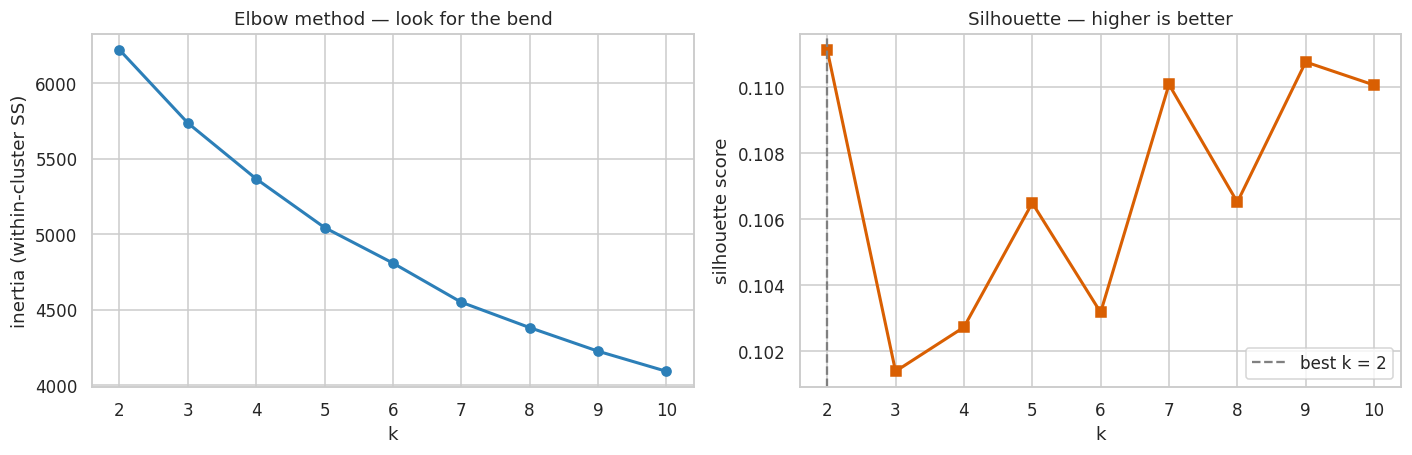

k= 2 | inertia    6222.7 | silhouette 0.1111
k= 3 | inertia    5737.8 | silhouette 0.1014
k= 4 | inertia    5367.5 | silhouette 0.1027
k= 5 | inertia    5044.8 | silhouette 0.1065
k= 6 | inertia    4809.4 | silhouette 0.1032
k= 7 | inertia    4549.8 | silhouette 0.1101
k= 8 | inertia    4381.8 | silhouette 0.1065
k= 9 | inertia    4225.3 | silhouette 0.1108
k=10 | inertia    4092.0 | silhouette 0.1101


In [22]:
k_range = range(2, 11)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xc_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Xc_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(list(k_range), inertias, "o-", color="#2c7fb8", lw=2)
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia (within-cluster SS)")
axes[0].set_title("Elbow method — look for the bend")

axes[1].plot(list(k_range), silhouettes, "s-", color="#d95f02", lw=2)
best_k = list(k_range)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, ls="--", color="gray", label=f"best k = {best_k}")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette — higher is better"); axes[1].legend()
fig.tight_layout(); plt.show()

for k, i, s in zip(k_range, inertias, silhouettes):
    print(f"k={k:>2} | inertia {i:9.1f} | silhouette {s:.4f}")

Neither plot shows a convincing answer: the inertia curve has **no elbow**, and every
silhouette score sits around 0.10 — that is the signature of data with *no natural
clusters*. The habits vary smoothly and continuously; there are no islands.

We will still use **k = 4**, but for an honest reason: not because the data "has" four
groups, but because four segments are a *useful way to slice a continuum* for advising
students. Always be clear about which of those two things you are claiming.

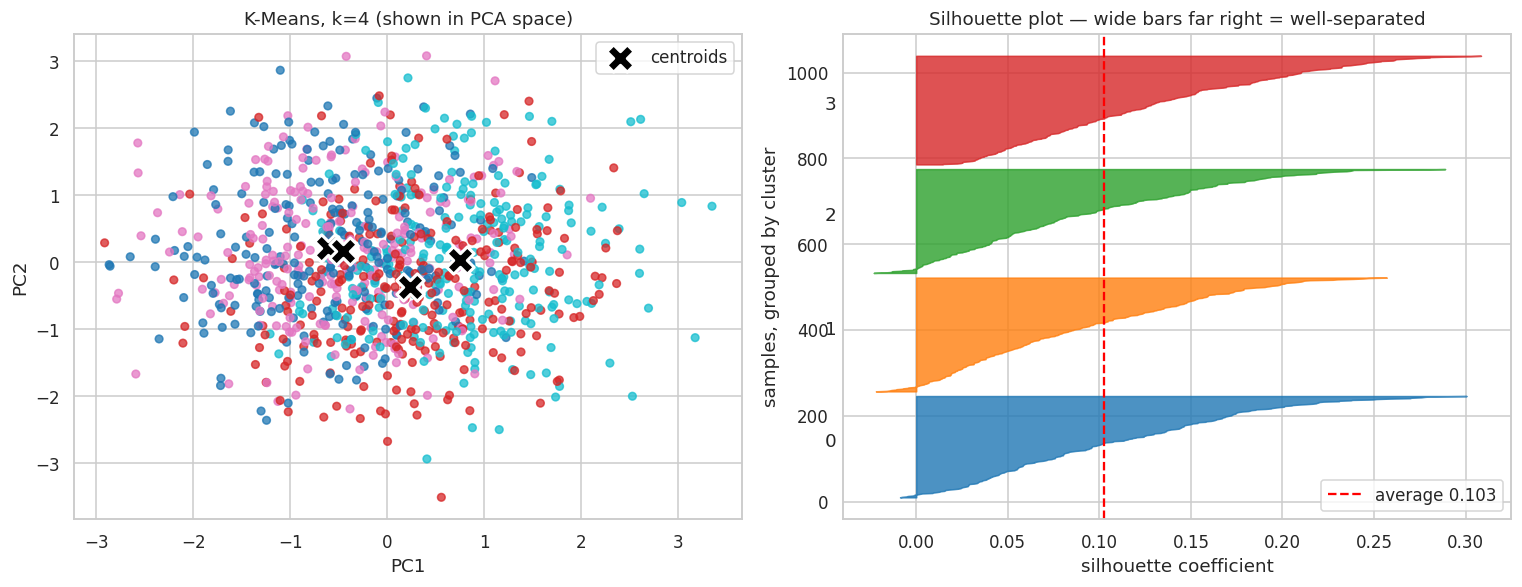

In [23]:
K = 4          # a practically useful number of student segments, NOT a discovered truth
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(Xc_scaled)
labels_km = kmeans.labels_

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sc = axes[0].scatter(Xc_2d[:, 0], Xc_2d[:, 1], c=labels_km, cmap="tab10", s=25, alpha=0.75)
centers_2d = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centers_2d[:, 0], centers_2d[:, 1], marker="X", s=320,
                c="black", edgecolor="white", linewidth=2, label="centroids")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title(f"K-Means, k={K} (shown in PCA space)"); axes[0].legend()

# Silhouette plot — per-sample quality, cluster by cluster
sil_vals = silhouette_samples(Xc_scaled, labels_km)
y_lower = 10
for i in range(K):
    vals = np.sort(sil_vals[labels_km == i])
    y_upper = y_lower + len(vals)
    axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                          color=plt.cm.tab10(i / 10), alpha=0.8)
    axes[1].text(-0.05, y_lower + 0.5 * len(vals), str(i))
    y_lower = y_upper + 10
axes[1].axvline(sil_vals.mean(), color="red", ls="--",
                label=f"average {sil_vals.mean():.3f}")
axes[1].set_xlabel("silhouette coefficient"); axes[1].set_ylabel("samples, grouped by cluster")
axes[1].set_title("Silhouette plot — wide bars far right = well-separated")
axes[1].legend()

fig.tight_layout(); plt.show()

         study_hours_per_day  social_media_hours  netflix_hours  attendance_percentage  sleep_hours  exercise_frequency  mental_health_rating  exam_score  n_students  pass_rate
cluster                                                                                                                                                                         
0                       3.16                2.33           2.59                  83.10         5.99                4.65                  4.01       63.15         237      0.595
1                       3.70                2.74           2.07                  82.87         6.12                1.83                  8.36       73.07         266      0.801
2                       3.55                2.19           1.02                  85.20         7.17                4.66                  6.12       77.19         243      0.835
3                       3.76                2.71           1.61                  85.39         6.62                

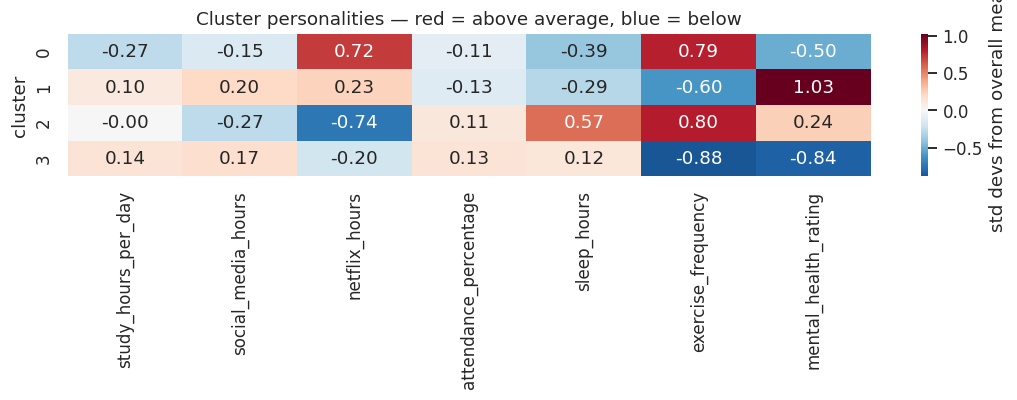

In [24]:
# The step everyone skips and shouldn't: WHAT ARE these clusters?
data["cluster"] = labels_km
profile = data.groupby("cluster")[CLUSTER_FEATURES + ["exam_score"]].mean().round(2)
profile["n_students"] = data.groupby("cluster").size()
profile["pass_rate"] = data.groupby("cluster").apply(
    lambda g: (g["exam_score"] >= 60).mean(), include_groups=False).round(3)
print(profile.to_string())

# A heatmap of z-scores makes the personality of each cluster obvious
z_profile = ((profile[CLUSTER_FEATURES] - data[CLUSTER_FEATURES].mean())
             / data[CLUSTER_FEATURES].std())
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.heatmap(z_profile, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "std devs from overall mean"})
ax.set_title("Cluster personalities — red = above average, blue = below")
fig.tight_layout(); plt.show()

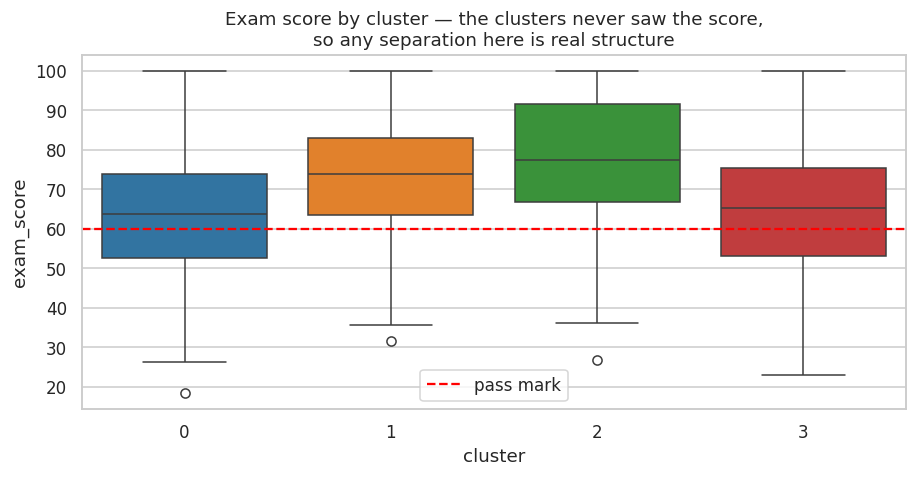

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.boxplot(data=data, x="cluster", y="exam_score", ax=ax,
            hue="cluster", legend=False, palette="tab10")
ax.axhline(60, ls="--", color="red", label="pass mark")
ax.set_title("Exam score by cluster — the clusters never saw the score,\n"
             "so any separation here is real structure")
ax.legend(); fig.tight_layout(); plt.show()

## F2 · Hierarchical clustering

Agglomerative clustering starts with every point as its own cluster and repeatedly merges
the two closest, building a tree (**dendrogram**). You choose the number of clusters
*afterwards* by cutting the tree at a height.

**Linkage** defines "distance between clusters":

| Linkage | Distance between clusters | Tends to produce |
|---|---|---|
| `single` | closest pair | long straggly chains |
| `complete` | furthest pair | compact, equal-diameter blobs |
| `average` | mean over all pairs | a middle ground |
| `ward` | merge that increases variance least | **balanced, similar-size — the usual default** |

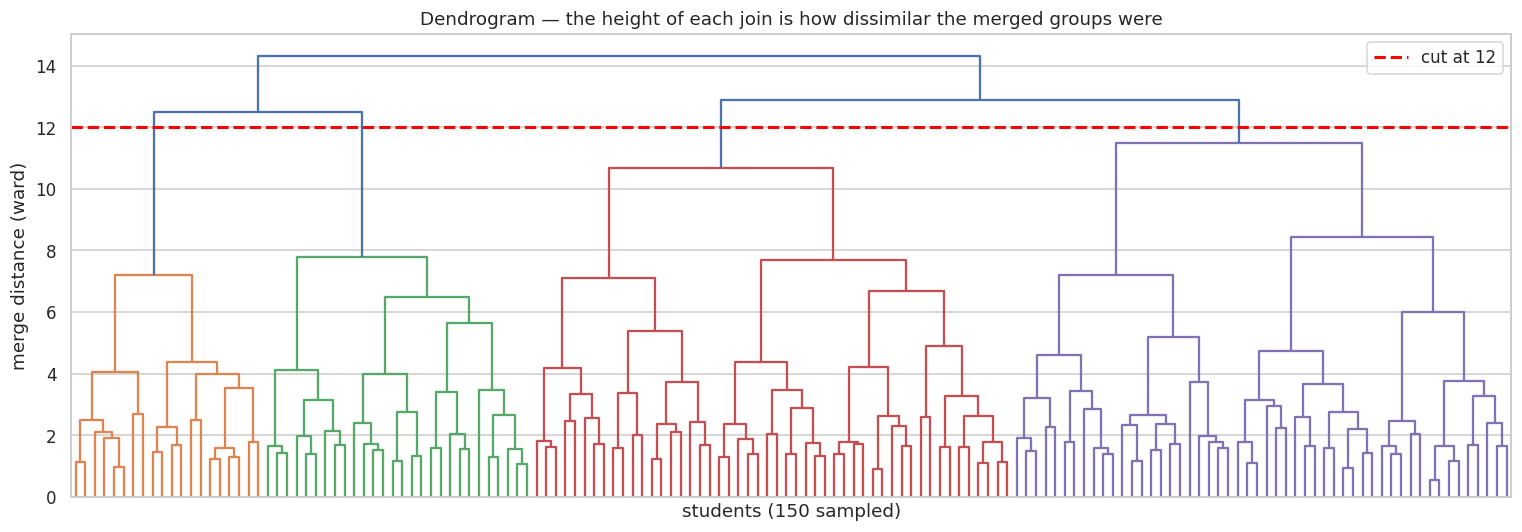

cut at height  8 -> 7 clusters
cut at height 10 -> 6 clusters
cut at height 12 -> 4 clusters
cut at height 13 -> 2 clusters
cut at height 16 -> 1 clusters

The dendrogram does not tell you the right number of clusters — it shows you every option at once.


In [26]:
# The dendrogram gets unreadable past a few hundred points, so sample
sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(Xc_scaled), 150, replace=False)
Z = linkage(Xc_scaled[sample_idx], method="ward")

CUT = 12          # try changing this and watch the cluster count change
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, color_threshold=CUT, no_labels=True)
ax.axhline(CUT, ls="--", color="red", lw=2, label=f"cut at {CUT}")
ax.set_xlabel("students (150 sampled)"); ax.set_ylabel("merge distance (ward)")
ax.set_title("Dendrogram — the height of each join is how dissimilar the merged groups were")
ax.legend(); fig.tight_layout(); plt.show()

for h in [8, 10, 12, 13, 16]:
    print(f"cut at height {h:>2} -> "
          f"{len(np.unique(fcluster(Z, h, criterion='distance')))} clusters")
print("\nThe dendrogram does not tell you the right number of clusters — "
      "it shows you every option at once.")

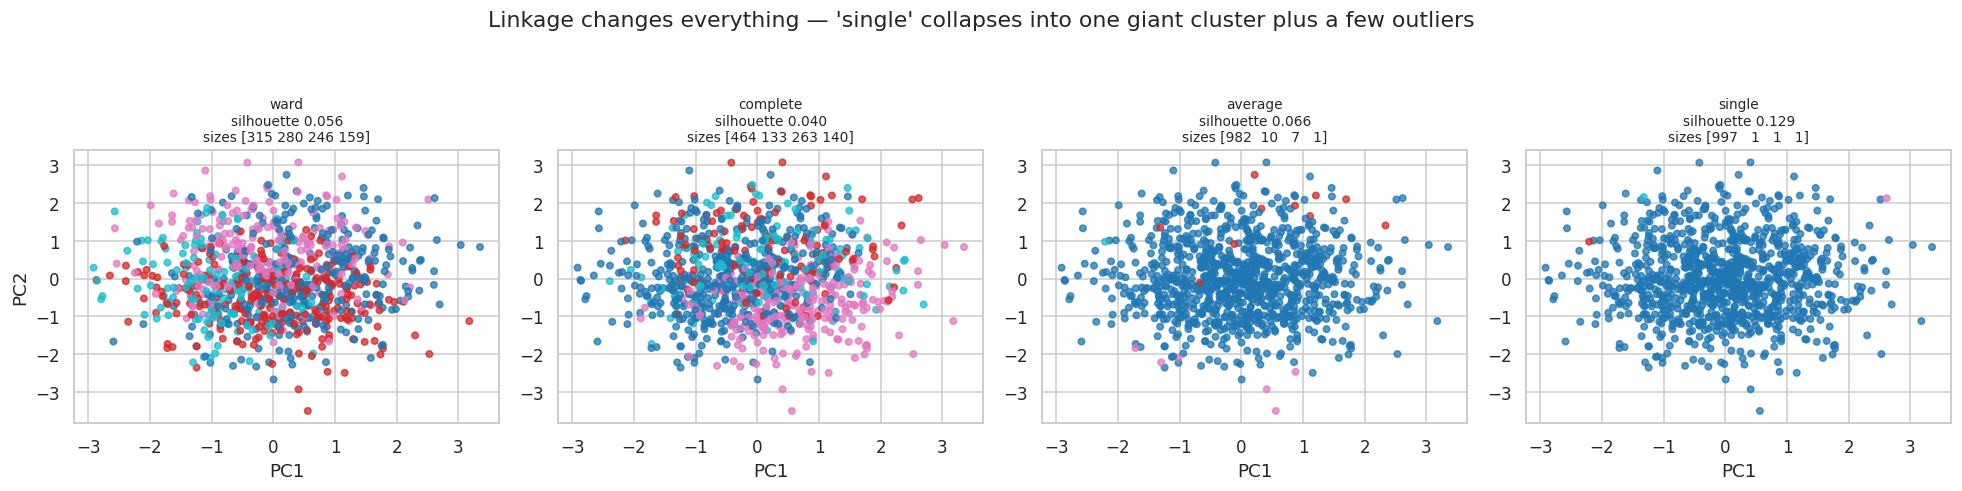

In [27]:
# Compare the four linkage methods
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, link in zip(axes, ["ward", "complete", "average", "single"]):
    lab = AgglomerativeClustering(n_clusters=K, linkage=link).fit_predict(Xc_scaled)
    sil = silhouette_score(Xc_scaled, lab)
    ax.scatter(Xc_2d[:, 0], Xc_2d[:, 1], c=lab, cmap="tab10", s=18, alpha=0.75)
    sizes = np.bincount(lab)
    ax.set_title(f"{link}\nsilhouette {sil:.3f}\nsizes {sizes}", fontsize=9)
    ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.suptitle("Linkage changes everything — 'single' collapses into one giant cluster "
             "plus a few outliers", y=1.06)
fig.tight_layout(); plt.show()

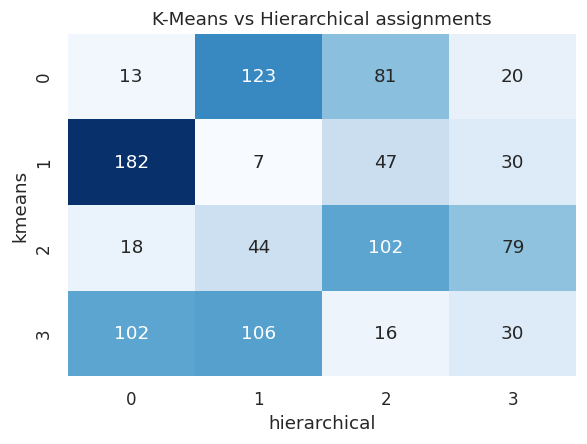

Adjusted Rand Index: 0.177
(1.0 = identical partitions, 0.0 = no more agreement than chance)


In [28]:
# Do K-Means and Ward hierarchical agree?
labels_hc = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(Xc_scaled)

agreement = pd.crosstab(pd.Series(labels_km, name="kmeans"),
                        pd.Series(labels_hc, name="hierarchical"))
fig, ax = plt.subplots(figsize=(5.5, 4.2))
sns.heatmap(agreement, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("K-Means vs Hierarchical assignments")
fig.tight_layout(); plt.show()

from sklearn.metrics import adjusted_rand_score
print("Adjusted Rand Index:", round(adjusted_rand_score(labels_km, labels_hc), 4))
print("(1.0 = identical partitions, 0.0 = no more agreement than chance)")

## F3 · DBSCAN

**D**ensity-**B**ased **S**patial **C**lustering of **A**pplications with **N**oise.

Two parameters:
- `eps` — the radius of a neighbourhood.
- `min_samples` — how many points must be inside that radius for a point to be a *core* point.

Then: core points that are within `eps` of each other join the same cluster; points near a
core point join as *border* points; everything else is labelled **−1 = noise**.

**Why it is different:** it finds arbitrarily-shaped clusters, decides `k` on its own, and
explicitly flags outliers. **Why it is hard:** it is very sensitive to `eps`, and struggles
when clusters have different densities.

The standard way to pick `eps` is the **k-distance elbow**: sort every point's distance to
its k-th nearest neighbour and look for the knee.

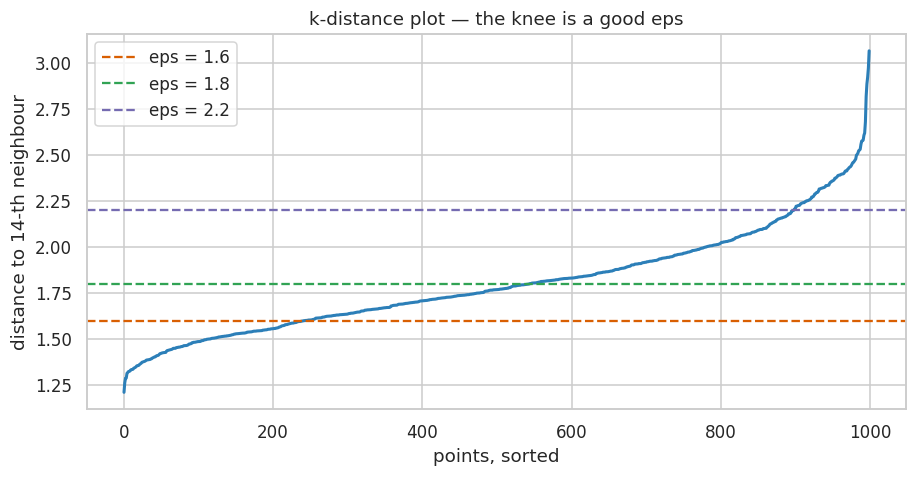

In [29]:
min_samples = 2 * Xc_scaled.shape[1]          # rule of thumb: 2 x n_features
nn = NearestNeighbors(n_neighbors=min_samples).fit(Xc_scaled)
distances, _ = nn.kneighbors(Xc_scaled)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(k_dist, lw=2, color="#2c7fb8")
for eps_try, colr in zip([1.6, 1.8, 2.2], ["#d95f02", "#31a354", "#756bb1"]):
    ax.axhline(eps_try, ls="--", color=colr, label=f"eps = {eps_try}")
ax.set_xlabel("points, sorted"); ax.set_ylabel(f"distance to {min_samples}-th neighbour")
ax.set_title("k-distance plot — the knee is a good eps")
ax.legend(); fig.tight_layout(); plt.show()

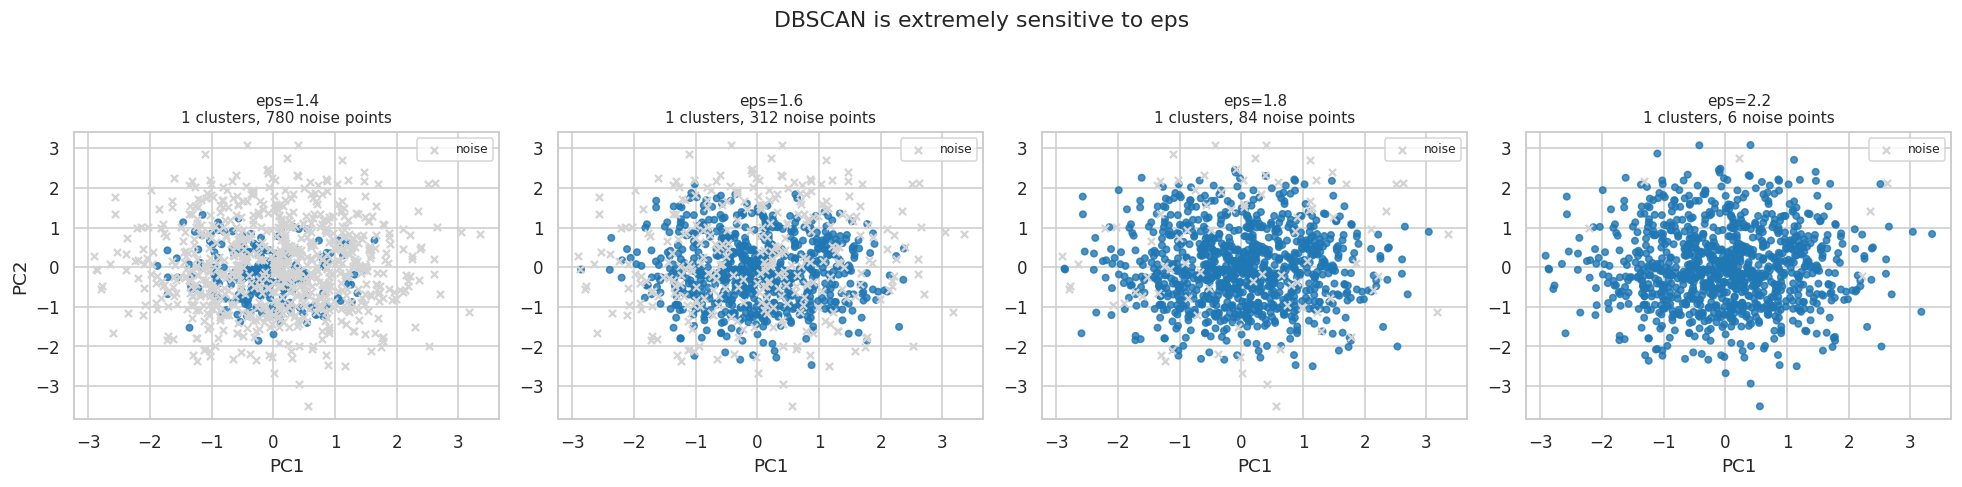

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, eps in zip(axes, [1.4, 1.6, 1.8, 2.2]):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(Xc_scaled)
    lab = db.labels_
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = int((lab == -1).sum())
    noise_mask = lab == -1
    ax.scatter(Xc_2d[~noise_mask, 0], Xc_2d[~noise_mask, 1],
               c=lab[~noise_mask], cmap="tab10", s=18, alpha=0.8)
    ax.scatter(Xc_2d[noise_mask, 0], Xc_2d[noise_mask, 1],
               c="lightgray", marker="x", s=22, label="noise")
    ax.set_title(f"eps={eps}\n{n_clusters} clusters, {n_noise} noise points", fontsize=10)
    ax.set_xlabel("PC1")
    if n_noise:
        ax.legend(fontsize=8)
axes[0].set_ylabel("PC2")
fig.suptitle("DBSCAN is extremely sensitive to eps", y=1.05)
fig.tight_layout(); plt.show()

In [31]:
EPS = 1.8        # from the k-distance knee: keeps ~92% of students, flags the rest
db = DBSCAN(eps=EPS, min_samples=min_samples).fit(Xc_scaled)
labels_db = db.labels_
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)

print(f"DBSCAN found {n_clusters_db} cluster(s) and flagged "
      f"{(labels_db == -1).sum()} points as noise")

if (labels_db != -1).sum() > 0 and n_clusters_db > 1:
    core = labels_db != -1
    print("silhouette (noise excluded):",
          round(silhouette_score(Xc_scaled[core], labels_db[core]), 4))

# What do the outliers look like? This is DBSCAN's real value here.
data["dbscan"] = labels_db
outliers = data[data["dbscan"] == -1]
print(f"\nProfile of the {len(outliers)} 'unusual' students vs everyone else:")
cmp = pd.DataFrame({
    "outliers": outliers[CLUSTER_FEATURES + ["exam_score"]].mean(),
    "everyone else": data[data["dbscan"] != -1][CLUSTER_FEATURES + ["exam_score"]].mean(),
}).round(2)
cmp["difference"] = (cmp["outliers"] - cmp["everyone else"]).round(2)
print(cmp.to_string())

DBSCAN found 1 cluster(s) and flagged 84 points as noise

Profile of the 84 'unusual' students vs everyone else:
                       outliers  everyone else  difference
study_hours_per_day        3.51           3.55       -0.04
social_media_hours         2.96           2.46        0.50
netflix_hours              2.25           1.78        0.47
attendance_percentage     82.09          84.32       -2.23
sleep_hours                6.83           6.44        0.39
exercise_frequency         3.01           3.04       -0.03
mental_health_rating       5.92           5.39        0.53
exam_score                67.76          69.77       -2.01


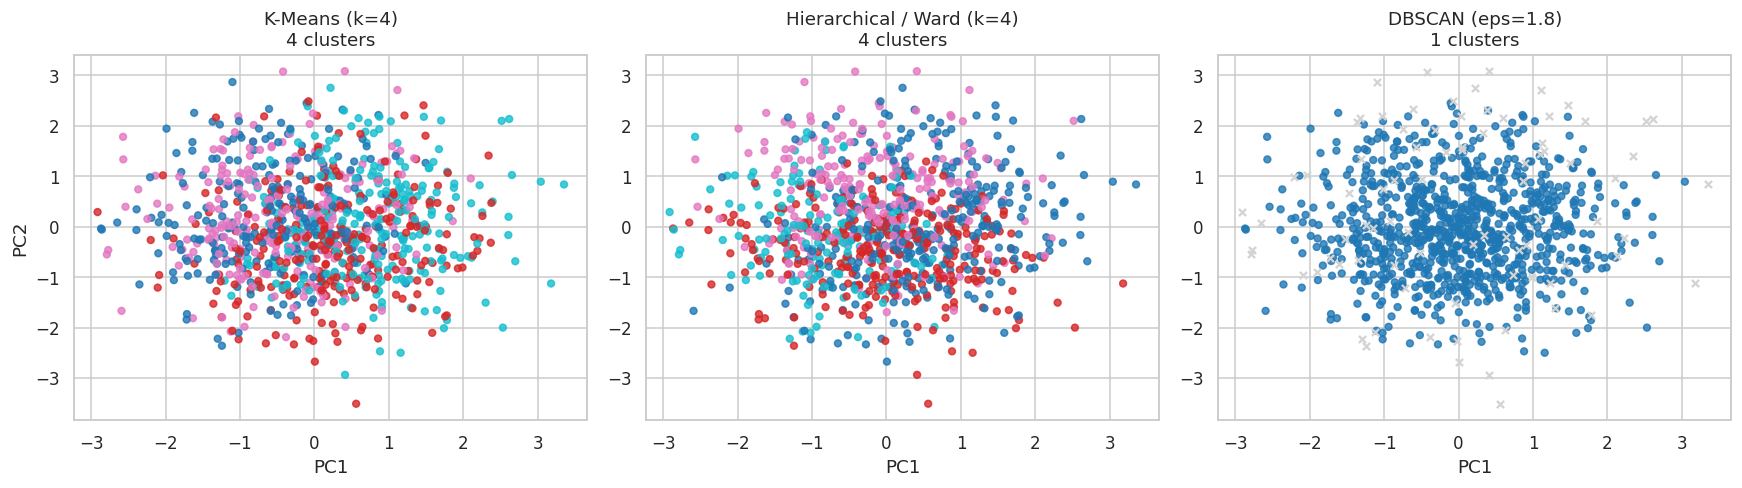

Verdict on this dataset:
  These student habits are drawn from smooth, overlapping distributions — there are no
  genuinely separate 'islands' of students. Silhouette scores near 0.1-0.2 confirm it.
  K-Means still gives a USEFUL segmentation (it partitions the space sensibly, and the
  segments differ in pass rate), but do not oversell it as 'discovering hidden groups'.
  DBSCAN's honest answer is 'one big blob plus some outliers' — and knowing that is a
  real result, not a failure.


In [32]:
# Final comparison of all three algorithms
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (lab, title) in zip(axes, [
        (labels_km, f"K-Means (k={K})"),
        (labels_hc, f"Hierarchical / Ward (k={K})"),
        (labels_db, f"DBSCAN (eps={EPS})")]):
    noise = lab == -1
    ax.scatter(Xc_2d[~noise, 0], Xc_2d[~noise, 1], c=lab[~noise], cmap="tab10",
               s=20, alpha=0.8)
    if noise.any():
        ax.scatter(Xc_2d[noise, 0], Xc_2d[noise, 1], c="lightgray", marker="x", s=22)
    n = len(set(lab)) - (1 if -1 in lab else 0)
    ax.set_title(f"{title}\n{n} clusters"); ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.tight_layout(); plt.show()

print("""Verdict on this dataset:
  These student habits are drawn from smooth, overlapping distributions — there are no
  genuinely separate 'islands' of students. Silhouette scores near 0.1-0.2 confirm it.
  K-Means still gives a USEFUL segmentation (it partitions the space sensibly, and the
  segments differ in pass rate), but do not oversell it as 'discovering hidden groups'.
  DBSCAN's honest answer is 'one big blob plus some outliers' — and knowing that is a
  real result, not a failure.""")

---
# Part G · Saving the finished model

`joblib` serialises the entire fitted pipeline — imputers, scaler, encoder, model — into
one file. Reload it anywhere and call `.predict()` on raw data.

In [33]:
import joblib

best_model = grid.best_estimator_
joblib.dump(best_model, "student_pass_predictor.joblib")
print("saved -> student_pass_predictor.joblib")

reloaded = joblib.load("student_pass_predictor.joblib")
print("reloaded test accuracy:", round(reloaded.score(Xf_te, yf_te), 4))

# End-to-end prediction on a brand-new student, straight from a dict
new_student = pd.DataFrame([{
    "age": 20, "study_hours_per_day": 5.5, "social_media_hours": 1.2,
    "netflix_hours": 0.8, "attendance_percentage": 92.0, "sleep_hours": 7.5,
    "exercise_frequency": 4, "mental_health_rating": 8,
    "gender": "Female", "part_time_job": "No", "diet_quality": "Good",
    "parental_education_level": "Bachelor", "internet_quality": "Good",
    "extracurricular_participation": "Yes",
}])

prob = reloaded.predict_proba(new_student)[0, 1]
print(f"\nNew student -> P(pass) = {prob:.3f} "
      f"-> predicted {'PASS' if prob >= 0.5 else 'FAIL'}")

at_risk = new_student.copy()
at_risk.loc[0, ["study_hours_per_day", "social_media_hours",
                "attendance_percentage", "mental_health_rating"]] = [1.0, 5.0, 65.0, 3]
print(f"An at-risk profile -> P(pass) = {reloaded.predict_proba(at_risk)[0, 1]:.3f}")

saved -> student_pass_predictor.joblib
reloaded test accuracy: 0.905

New student -> P(pass) = 1.000 -> predicted PASS
An at-risk profile -> P(pass) = 0.019


---
## Mini-challenge

1. Re-run the GridSearch optimising `recall` on the **failing** class instead of ROC-AUC
   (`scoring="recall"` with the labels flipped, or a custom scorer). Does the best `C`
   change?
2. Swap `GridSearchCV` for `RandomizedSearchCV` over a continuous `C` distribution
   (`scipy.stats.loguniform`). Same result in a fraction of the fits?
3. Add a `RandomForestClassifier` to the pipeline and tune `max_depth` and
   `n_estimators`. Compare its cross-validated ROC-AUC to logistic regression.
4. Cluster on a **different** feature subset (only the "leisure" columns: social media,
   netflix, exercise, sleep). Do you get cleaner clusters?
5. Use `KMeans` cluster labels as an extra one-hot feature in the classification pipeline.
   Does the cross-validated AUC improve? (This is a real technique — cluster-based feature
   engineering.)
6. Write the whole Week 9–10 workflow as a single reusable function
   `evaluate(model, X, y)` that returns a tidy metrics DataFrame.

In [34]:
# --- your workspace for the mini-challenge ---

---
## Recap

### Evaluation
| Tool | Use |
|---|---|
| `train_test_split(stratify=y)` | one honest hold-out, class ratio preserved |
| `StratifiedKFold` | classification CV — always prefer over plain `KFold` |
| `cross_validate` | several metrics + train scores in one pass |
| `confusion_matrix` | *what kind* of mistakes, not just how many |
| precision / recall / F1 | pick based on the real cost of each error type |
| `classification_report` | per-class breakdown; read the macro average |
| ROC-AUC | threshold-free ranking quality |
| PR curve / average precision | better than ROC when classes are imbalanced |
| `DummyClassifier` | the baseline you must beat |
| `learning_curve` | do I need more data, or a better model? |

### Workflow
| Tool | Use |
|---|---|
| `Pipeline` | chain transforms + model into one leak-proof object |
| `ColumnTransformer` | different treatment for numeric vs categorical columns |
| `SimpleImputer` | fill missing values *inside* the pipeline, per fold |
| `GridSearchCV` | exhaustive tuning, scored by cross-validation |
| `joblib.dump/load` | ship the fitted pipeline |

### Clustering
| Algorithm | Choose `k` by | Watch out for |
|---|---|---|
| K-Means | elbow + silhouette | assumes spherical, equal-size clusters |
| Hierarchical | cut the dendrogram | `linkage` changes the answer completely |
| DBSCAN | k-distance elbow for `eps` | very sensitive to `eps`; struggles with mixed densities |

### The habits that separate a good ML student from a Kaggle-copier

1. **Never** fit a transform on data the model will be tested on.
2. Report a mean **and** a standard deviation, never a single split's score.
3. Beat `DummyClassifier` before you celebrate.
4. Choose the metric from the problem, not from what looks highest.
5. The threshold is a business decision, not a default.
6. For clustering, always profile the clusters — an unexplainable cluster is not a finding.
7. Wrap everything in a `Pipeline` so the mistakes above become impossible.

**You have now covered Weeks 3–10.** Python → NumPy → Pandas → visualisation → the maths →
supervised models → rigorous evaluation → unsupervised learning. That is a complete,
defensible ML workflow you can point to in an interview.